Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


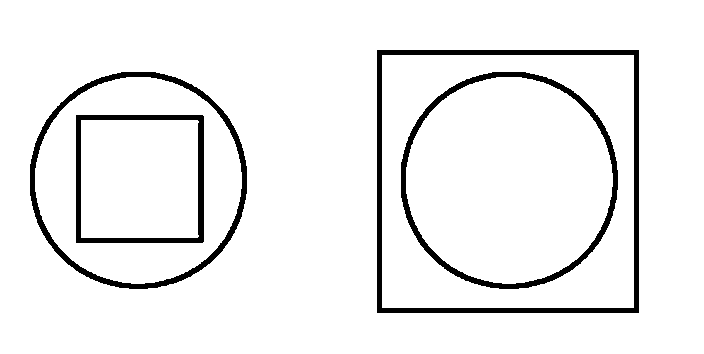

Visualizando as arestas detectadas pelo Canny:


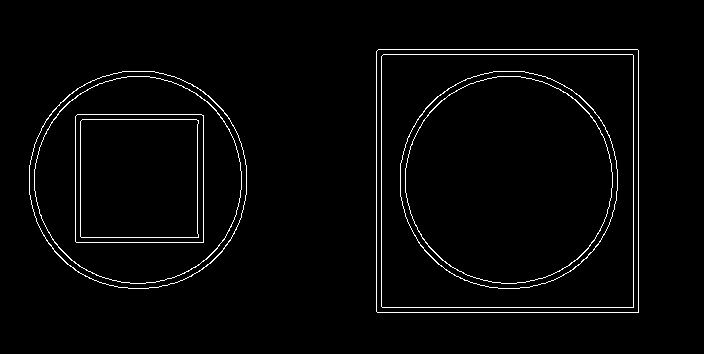

----------------------------------------
--- LADO ESQUERDO ---
Borda Interna: 104.000000 pixels
Borda Externa: 109.000000 pixels
--- LADO DIREITO ---
Borda Interna: 104.000000 pixels
Borda Externa: 109.000000 pixels
----------------------------------------
Visualizando detecção dos círculos:


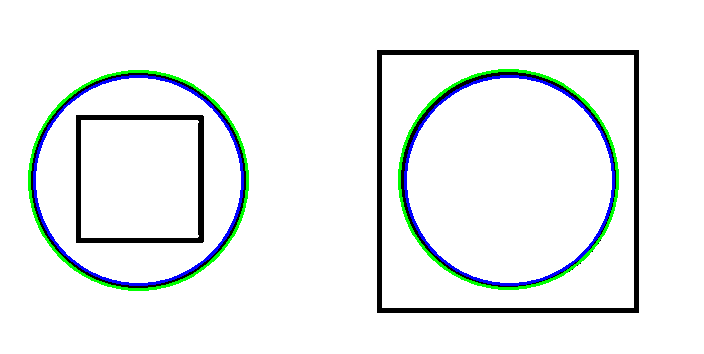

----------------------------------------
Ângulo médio agudo entre os pares de linhas: 0.0000 graus
----------------------------------------
Visualizando prova matemática final:


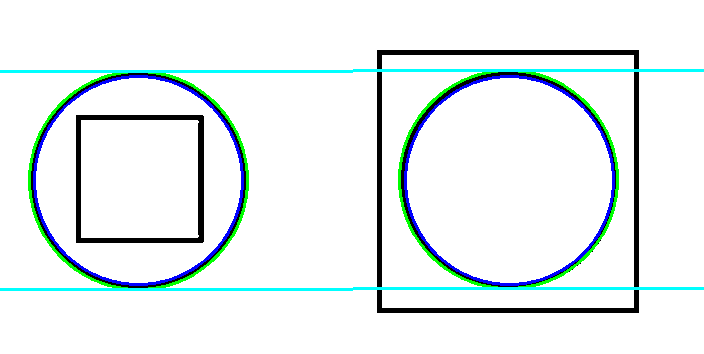

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np
from skimage.transform import hough_circle, hough_circle_peaks

#Carrega a imagem
imagem = cv2.imread('/content/drive/MyDrive/Pesquisa/Visão Computacional/imagens/Quest1C/circle_illusion.png')
#Imprime a imagem
cv2_imshow(imagem)

output = imagem.copy()
h_img, w_img = output.shape[:2]

# =========================================================================
# MÓDULO 1: PRÉ-PROCESSAMENTO E BORDAS DE CANNY
# Objetivo: Preparar a imagem e visualizar as arestas detectadas.
# =========================================================================

# --- PRÉ-PROCESSAMENTO ---
gray_img = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

threshold1 = 50
threshold2 = 200
arestas = cv2.Canny(gray_img, threshold1, threshold2)

# --- VISUALIZAÇÃO 1 ---
print("Visualizando as arestas detectadas pelo Canny:")
cv2_imshow(arestas)
print("-" * 40)


# =========================================================================
# MÓDULO 2: DETECÇÃO DE CÍRCULOS (INTERNO E EXTERNO)
# Objetivo: Encontrar os raios, calcular a média e desenhar os círculos.
# =========================================================================

# 2. DETECÇÃO (Intervalo que cobre 100 a 120)
raios_teste = np.arange(100, 120)
hough_res = hough_circle(arestas, raios_teste)

# 3. PICOS (Permite concêntricos)
accs, cx, cy, radii = hough_circle_peaks(hough_res, raios_teste,
                                          total_num_peaks=4,
                                          min_xdistance=1,
                                          min_ydistance=1)

# 4. AGRUPAMENTO
candidatos = []
for x, y, r in zip(cx, cy, radii):
    candidatos.append({'x': x, 'y': y, 'r': r})

meio = w_img // 2
grupo_esq = [c for c in candidatos if c['x'] < meio]
grupo_dir = [c for c in candidatos if c['x'] > meio]

# --- FUNÇÃO DE PROCESSAMENTO COM OS PRINTS ---
def processar_grupo(grupo, nome):
    if not grupo: return None

    # Ordena pelo raio (Menor -> Maior)
    grupo.sort(key=lambda k: k['r'])

    interno = grupo[0]  # Menor raio
    externo = grupo[-1] # Maior raio

    # Desenhar
    # Externo (Verde)
    cv2.circle(output, (externo['x'], externo['y']), externo['r'], (0, 255, 0), 2)
    # Interno (Azul)
    cv2.circle(output, (interno['x'], interno['y']), interno['r'], (255, 0, 0), 2)

    # --- PRINTS DETALHADOS ---
    print(f"--- {nome} ---")
    print(f"Borda Interna: {interno['r']:2f} pixels")
    print(f"Borda Externa: {externo['r']:2f} pixels")

    # Retorna o externo para usarmos na prova das linhas paralelas
    return externo

# Executa e imprime os dados
dados_esq = processar_grupo(grupo_esq, "LADO ESQUERDO")
dados_dir = processar_grupo(grupo_dir, "LADO DIREITO")
print("-" * 40)

# --- VISUALIZAÇÃO 2 ---
print("Visualizando detecção dos círculos:")
cv2_imshow(output)


# =========================================================================
# MÓDULO 3: PROVA MATEMÁTICA (LINHAS PARALELAS)
# Objetivo: Traçar tangentes e calcular o ângulo entre elas.
# =========================================================================

print("-" * 40)

horizontal_lines = []

if dados_esq and dados_dir:
    # Calcular coordenadas Y das linhas tangentes (usando o círculo externo como referência)
    y_topo_esq = dados_esq['y'] - dados_esq['r']
    y_topo_dir = dados_dir['y'] - dados_dir['r']

    y_base_esq = dados_esq['y'] + dados_esq['r']
    y_base_dir = dados_dir['y'] + dados_dir['r']

    # Adicionar à lista para o cálculo matemático
    horizontal_lines.append((0, y_topo_esq, w_img, y_topo_dir))
    horizontal_lines.append((0, y_base_esq, w_img, y_base_dir))

    # Desenhar as linhas Ciano
    cv2.line(output, (0, y_topo_esq), (w_img, y_topo_dir), (255, 255, 0), 2)
    cv2.line(output, (0, y_base_esq), (w_img, y_base_dir), (255, 255, 0), 2)

    # --- ANÁLISE MATEMÁTICA ---
    slopes = []
    for x1, y1, x2, y2 in horizontal_lines:
        delta_x = x2 - x1
        if delta_x == 0:
            m = float('inf')
        else:
            m = (y2 - y1) / delta_x
        slopes.append(m)

    total_angle = 0.0
    pair_count = 0

    for i in range(len(slopes)):
        for j in range(i + 1, len(slopes)):
            m1 = slopes[i]
            m2 = slopes[j]

            numerator = m2 - m1
            denominator = 1 + m1 * m2

            if denominator == 0:
                angle_rad = np.pi / 2
            else:
                tan_theta = abs(numerator / denominator)
                angle_rad = np.arctan(tan_theta)

            total_angle += angle_rad
            pair_count += 1

    if pair_count > 0:
        average_angle_deg = np.degrees(total_angle / pair_count)
    else:
        average_angle_deg = 0.0

    print(f'Ângulo médio agudo entre os pares de linhas: {average_angle_deg:.4f} graus')

print("-" * 40)

# --- VISUALIZAÇÃO 3 ---
print("Visualizando prova matemática final:")
cv2_imshow(output)

In [5]:
candidatos

[{'x': np.int64(138), 'y': np.int64(180), 'r': np.int64(104)},
 {'x': np.int64(138), 'y': np.int64(180), 'r': np.int64(109)},
 {'x': np.int64(509), 'y': np.int64(180), 'r': np.int64(104)},
 {'x': np.int64(508), 'y': np.int64(179), 'r': np.int64(109)}]